<a href="https://colab.research.google.com/github/Jaya-323/Python_AI_ML_practice/blob/main/Practice7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as ny
import matplotlib.pyplot as plt
import seaborn as sns
print("Import successfull")

Import successfull


In [ ]:
data={
    "hours":[1,2,3,4,6,8,10],
    "attendance":[89,98,87,86,86,81,80],
    "marks":[89,98,87,86,86,81,80],
    "grade":[0,1,1,0,1,1,0],
    "gender":[0,1,0,1,1,1,0]
}
df=pd.DataFrame(data)
print(df)

   hours  attendance  marks  grade  gender
0      1          89     89      0       0
1      2          98     98      1       1
2      3          87     87      1       0
3      4          86     86      0       1
4      6          86     86      1       1
5      8          81     81      1       1
6     10          80     80      0       0


In [ ]:
print(df.shape,df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7 entries, 0 to 6
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   hours       7 non-null      int64
 1   attendance  7 non-null      int64
 2   marks       7 non-null      int64
 3   grade       7 non-null      int64
 4   gender      7 non-null      int64
dtypes: int64(5)
memory usage: 412.0 bytes
(7, 5) None


In [ ]:
X=df[["hours","attendance","gender","marks"]]
Y=df["grade"]
print(X)
print(Y)

   hours  attendance  gender  marks
0      1          89       0     89
1      2          98       1     98
2      3          87       0     87
3      4          86       1     86
4      6          86       1     86
5      8          81       1     81
6     10          80       0     80
0    0
1    1
2    1
3    0
4    1
5    1
6    0
Name: grade, dtype: int64


In [ ]:
from sklearn.model_selection import train_test_split
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.2,random_state=42)
print(X_train)
print(X_test)
print(Y_train)
print(Y_test)

   hours  attendance  gender  marks
5      8          81       1     81
2      3          87       0     87
4      6          86       1     86
3      4          86       1     86
6     10          80       0     80
   hours  attendance  gender  marks
0      1          89       0     89
1      2          98       1     98
5    1
2    1
4    1
3    0
6    0
Name: grade, dtype: int64
0    0
1    1
Name: grade, dtype: int64


Decision tree algorithm

In [ ]:
from sklearn.tree import DecisionTreeClassifier
model=DecisionTreeClassifier()
model.fit(X_train,Y_train)
print("Training completed")

Training completed


In [ ]:
prediction=model.predict(X_test)
print(prediction)

[1 1]


In [ ]:
from sklearn.metrics import accuracy_score
accuracy=accuracy_score(Y_test,prediction)
print(accuracy)

0.5


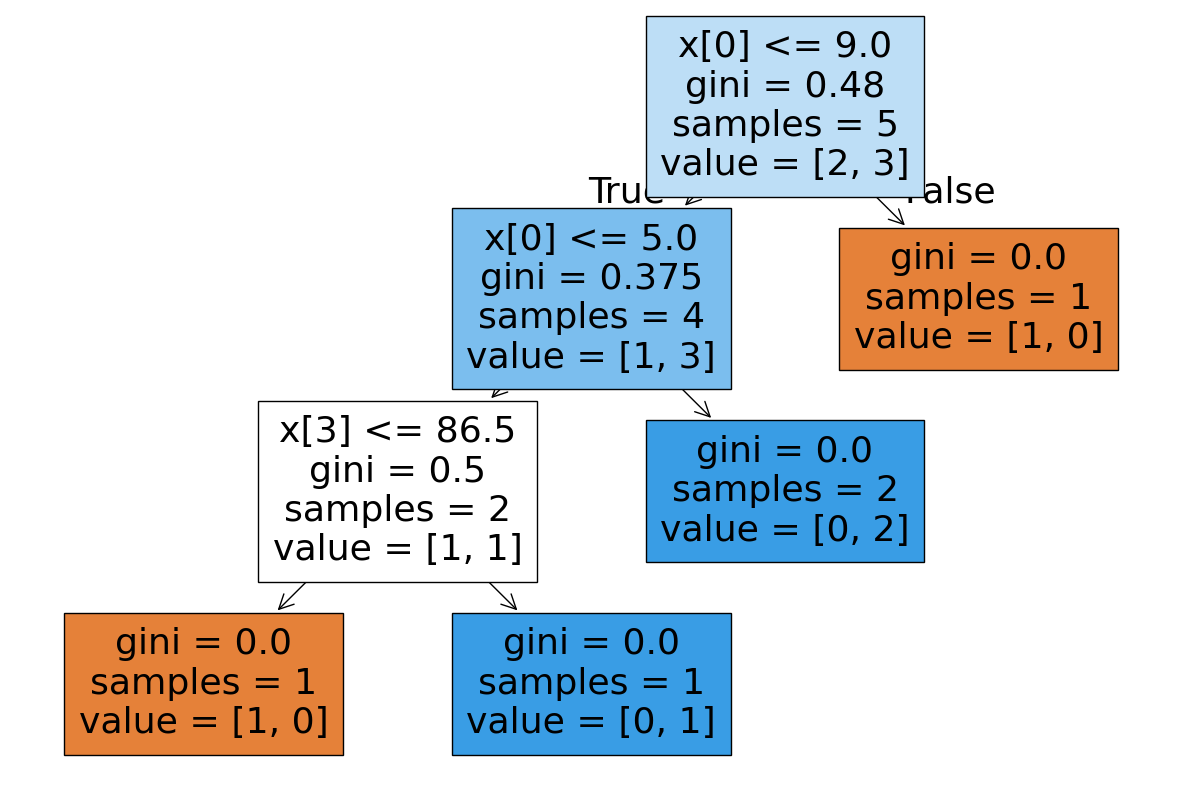

In [ ]:
from sklearn import tree
plt.figure(figsize=(15,10))
tree.plot_tree(model,filled=True)
plt.show()

In [ ]:
new_f=[[11,89,1,99]]
prediction_f=model.predict(new_f)
print(prediction_f)

[0]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


Random tree

In [ ]:
from sklearn.ensemble import RandomForestClassifier
model_f=RandomForestClassifier()
model_f.fit(X_train,Y_train)
print("Training completed")

Training completed


In [ ]:
f_prediction=model_f.predict(X_test)
print(f_prediction)

[1 1]


In [ ]:
from sklearn.metrics import accuracy_score
f_accuracy=accuracy_score(Y_test,f_prediction)
print(f_accuracy)

0.5


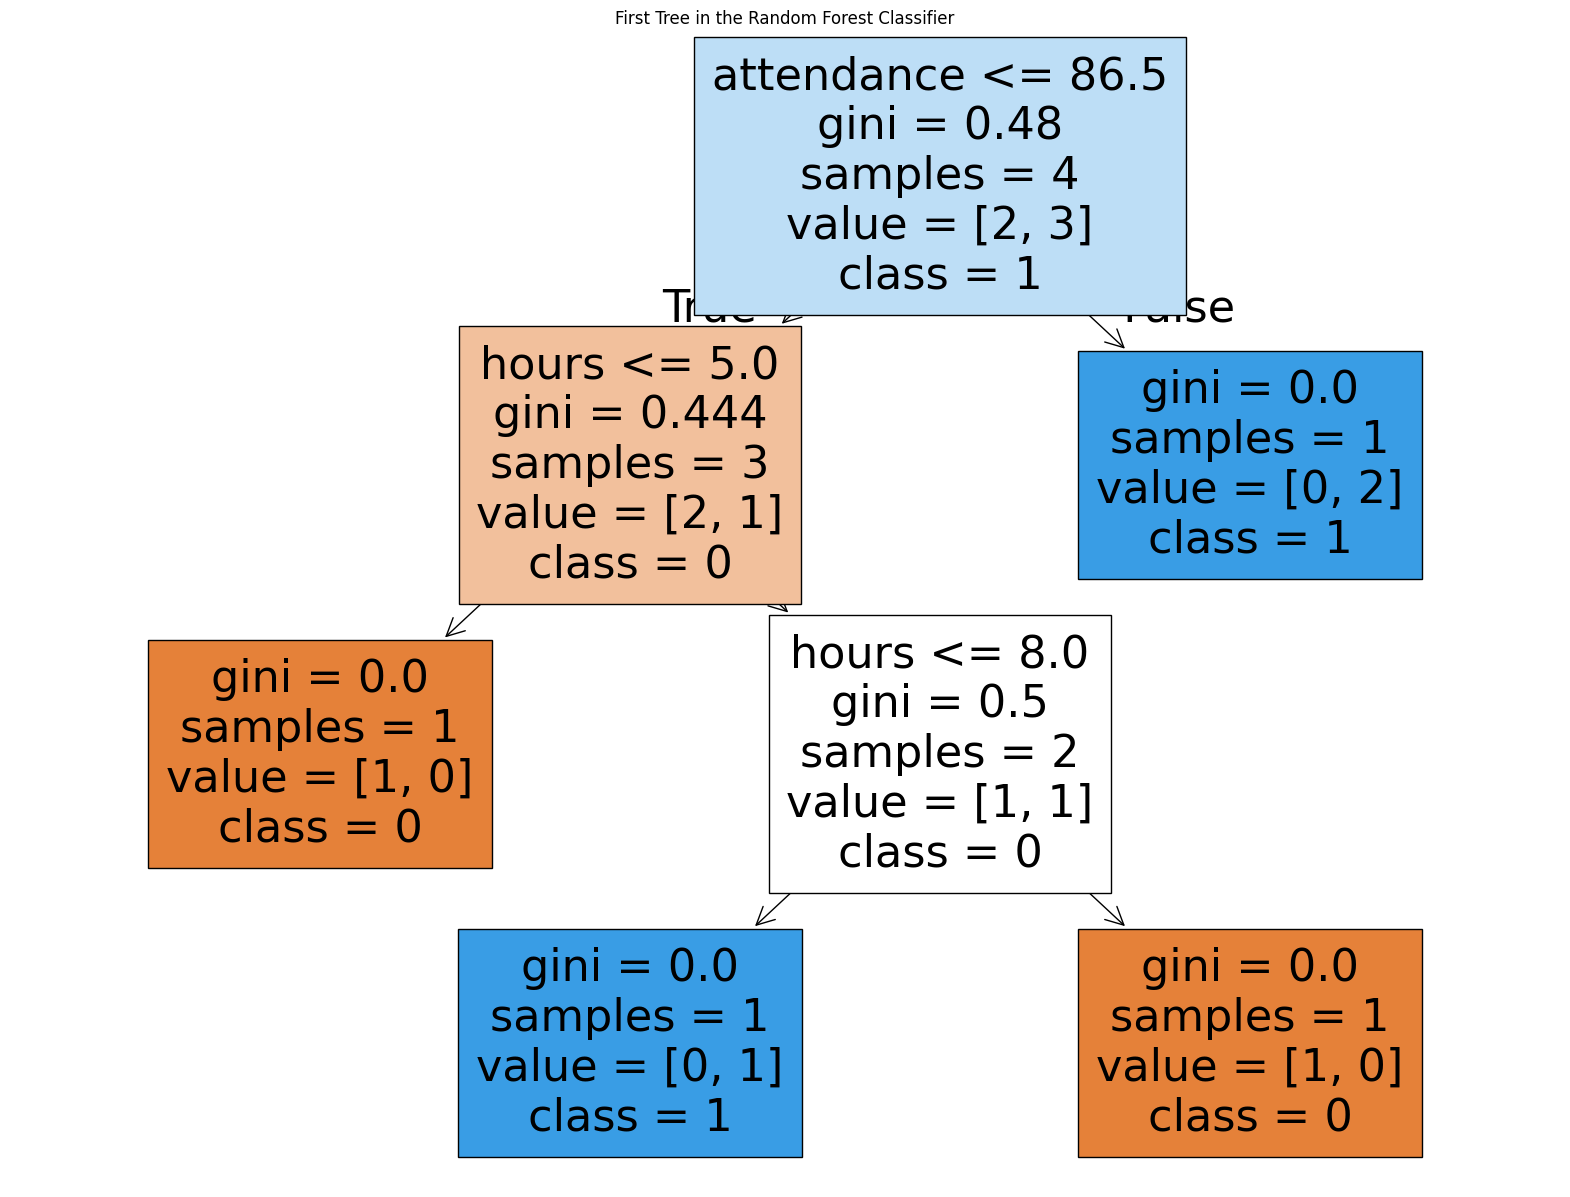

In [ ]:
plt.figure(figsize=(20,15))
tree.plot_tree(model_f.estimators_[0], filled=True, feature_names=X.columns, class_names=['0', '1'])
plt.title('First Tree in the Random Forest Classifier')
plt.show()

In [ ]:
importance = model_f.feature_importances_

feature_names = X.columns

for feature, score in zip(feature_names, importance):
    print(feature, ":", score)

hours : 0.4725877192982456
attendance : 0.17558479532163745
gender : 0.06038011695906434
marks : 0.2914473684210526


In [ ]:
new_r=[[11,89,1,99]]
prediction_r=model_f.predict(new_r)
print(prediction_r)

[1]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


KNN

In [ ]:
#Scaling
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_scaled=scaler.fit_transform(X_train)
X_scaled_test=scaler.transform(X_test)
print(X_scaled)
print(X_scaled_test)


[[ 0.70278193 -1.03509834  0.81649658 -1.03509834]
 [-1.2493901   1.03509834 -1.22474487  1.03509834]
 [-0.07808688  0.69006556  0.81649658  0.69006556]
 [-0.85895569  0.69006556  0.81649658  0.69006556]
 [ 1.48365074 -1.38013112 -1.22474487 -1.38013112]]
[[-2.0302589   1.7251639  -1.22474487  1.7251639 ]
 [-1.6398245   4.83045892  0.81649658  4.83045892]]


In [ ]:
from sklearn.neighbors import KNeighborsClassifier
model_knn=KNeighborsClassifier(n_neighbors=4)
model_knn.fit(X_scaled,Y_train)
print("Training completed")

Training completed


In [ ]:
knn_prediction=model_knn.predict(X_scaled_test)
print(knn_prediction)

[1 1]


In [ ]:
from sklearn.metrics import accuracy_score
knn_accuracy=accuracy_score(Y_test,knn_prediction)
print(knn_accuracy)

0.5


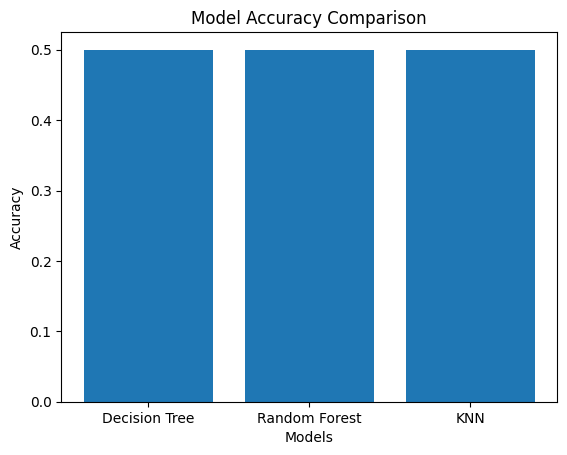

In [ ]:
models=["Decision Tree","Random Forest","KNN"]
accuracy_scores=[accuracy,f_accuracy,knn_accuracy]
plt.bar(models,accuracy_scores)
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison")
plt.show()
#

In [ ]:
comparision=pd.DataFrame({"Models":models,"Accuracy":accuracy_scores})
print(comparision)

          Models  Accuracy
0  Decision Tree       0.5
1  Random Forest       0.5
2            KNN       0.5


In [ ]:
new_t=[[11,89,1,99]]
new_t_scaled=scaler.transform(new_t)
prediction_k=model_knn.predict(new_t_scaled)
print(prediction_k)


[1]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [ ]:
model1=["Decision tree","Random forest","KNN"]
predictions=[prediction_f,prediction_k,prediction_r]
d=pd.DataFrame({"Models":model1,"Predictions":predictions})
print(d)

          Models Predictions
0  Decision tree         [0]
1  Random forest         [1]
2            KNN         [1]
